In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Problem 1
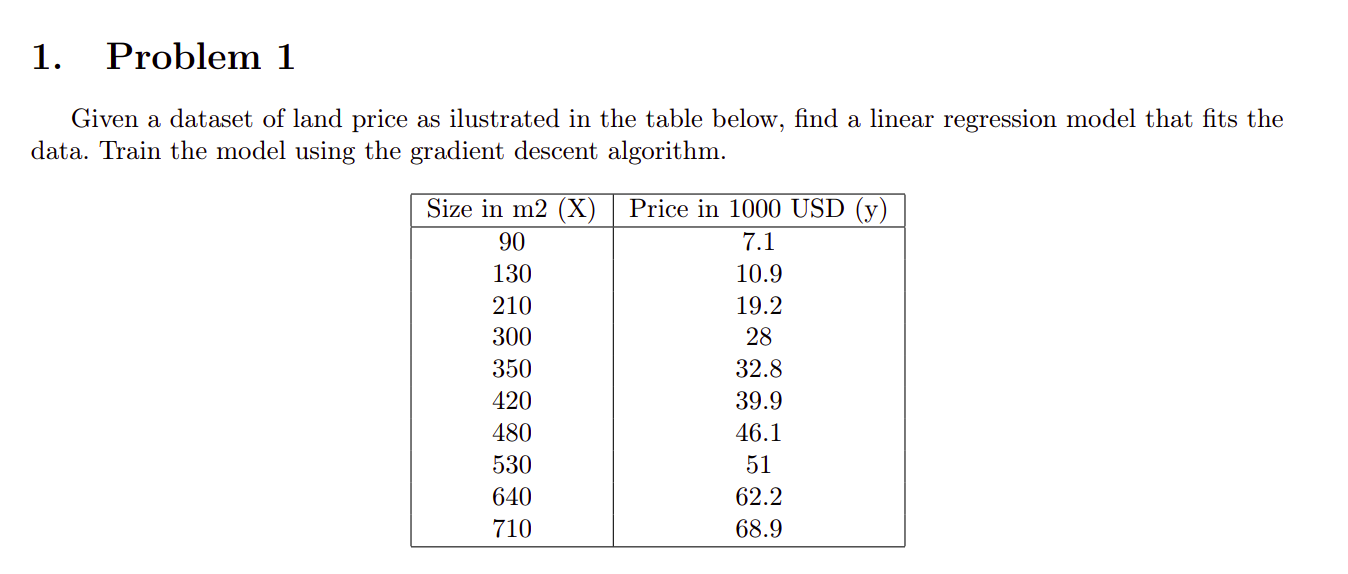

In [2]:
# 1. The Dataset
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710])
y = np.array([7.1, 10.9, 19.2, 28.0, 32.8, 39.9, 46.1, 51.0, 62.2, 68.9])

Text(0, 0.5, 'Price (Label)')

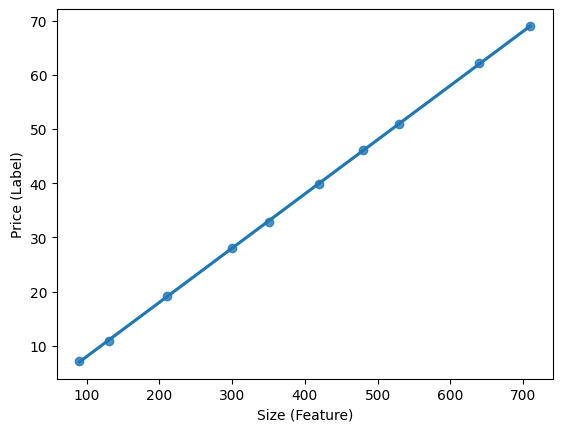

In [3]:
sns.regplot(x=X, y=y, ci=None)
plt.xlabel('Size (Feature)')
plt.ylabel('Price (Label)')

In [4]:
def gradient_descent(X: float, y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        One feature only \n
        feature and label will be scaled in this function
        >>> X: feature
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning rate
        >>> b_lr: bias learning rate
    '''
    X = X / np.max(X)

    w = 0
    b = 0

    for i in range(1, iter - 1):

        y_new = b + X * w
        
        weight = np.mean((y_new - y) * 2 * X)
        bias = np.mean((y_new - y) * 2)
        
        w = w - w_lr * weight
        b = b - b_lr * bias

    y_new = w * X + b
    loss = np.mean(pow(y - y_new, 2))

    return w, b, loss

In [5]:
gradient_descent(X, y, 2000, 0.01, 0.01)

(np.float64(65.94243997048122),
 np.float64(0.9325474297893798),
 np.float64(2.03033583287754))

### Problem 2
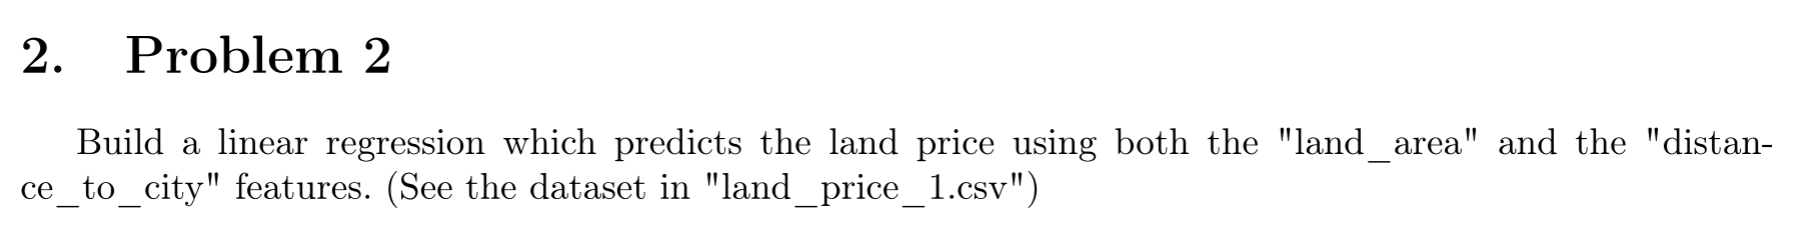

In [6]:
path = 'land_price_1.csv'
data = pd.read_csv(path)
data.head()

,land_area,dist_to_city,price
0,122,12.9,15.7
1,173,18.4,11.3
2,341,11.0,42.0
3,439,19.3,35.0
4,477,19.7,37.7


<Axes: xlabel='land_area', ylabel='price'>

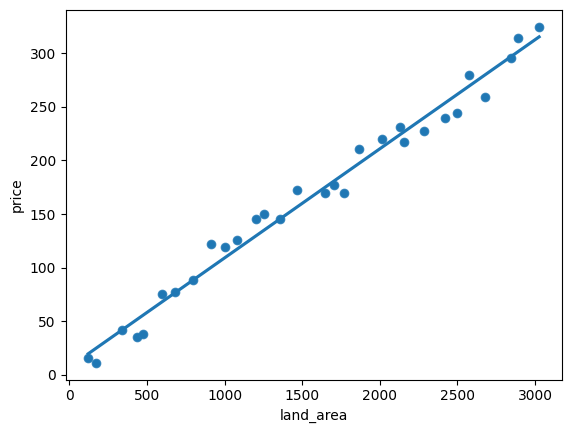

In [7]:
sns.scatterplot(x=data['land_area'], y=data['price'])
sns.regplot(x=data['land_area'], y=data['price'], ci=None)

<Axes: xlabel='dist_to_city', ylabel='price'>

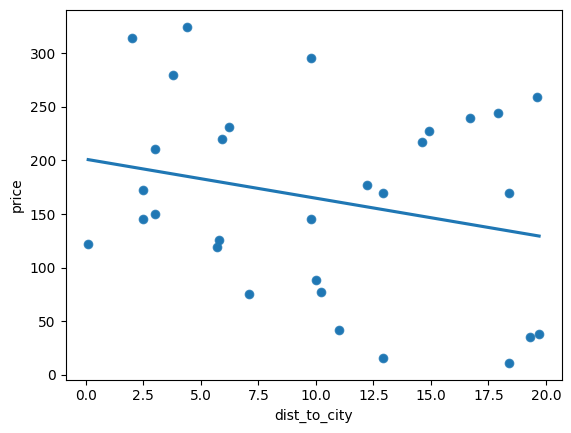

In [8]:
sns.scatterplot(x=data['dist_to_city'], y=data['price'])
sns.regplot(x=data['dist_to_city'], y=data['price'], ci=None)

<Axes: xlabel='land_area', ylabel='dist_to_city'>

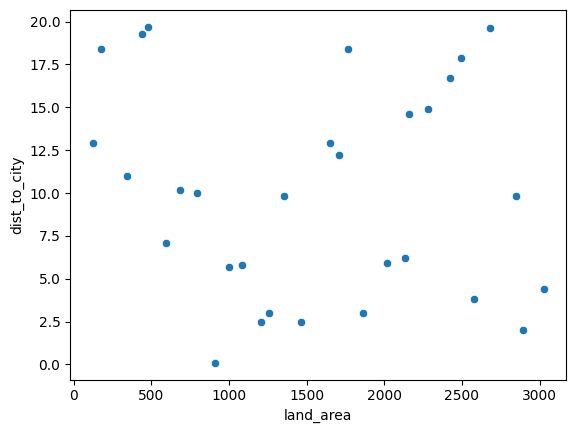

In [9]:
sns.scatterplot(x=data['land_area'], y=data['dist_to_city'])

In [10]:
print(f"{'='*4} Dataset {'='*4}")
path = 'land_price_1.csv'
data = pd.read_csv(path)
print(data.head())
# print(f"{"="*20}")

def gradient_descent(X: float, y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        feature and label will be scaled in this function
        >>> X: feature
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning rate
        >>> b_lr: bias learning rate
    '''
    x_max = np.max(X)
    x_min = np.min(X)
    X = (X - x_min) / (x_max - x_min)

    y_min = np.min(y)
    y_max = np.max(y)
    y = (y - y_min) / (y_max - y_min)
    # std = np.std(X)
    # mean = np.mean(X)
    # X = (X - mean) / std

    w_land = 0
    w_dist = 0
    b = 0

    for i in range(iter):

        y_new = b + X[:, 0] * w_land + X[:, 1] * w_dist
        
        weight_land = np.mean((y_new - y) * 2 * X[:, 0])
        weight_dist = np.mean((y_new - y) * 2 * X[:, 1])
        bias = np.mean((y_new - y) * 2)
        
        w_land = w_land - w_lr * weight_land
        w_dist = w_dist - w_lr * weight_dist
        b = b - b_lr * bias

    y_new = w_land * X[:, 0] + w_dist * X[:, 1] + b
    ss_res = np.sum(pow(y - y_new, 2))
    ss_tot = np.sum(pow(y - np.mean(y), 2))
    r_squared = 1 - (ss_res / ss_tot if ss_tot != 0 else 0)
    loss = np.mean(pow(y - y_new, 2))
    mse = np.mean(pow(y - y_new, 2))

    return w_land, w_dist, b, loss, r_squared, mse

X = data[['land_area', 'dist_to_city']].values
y = data['price'].values

a = gradient_descent(X, y, 10000, 0.01, 0.01)
print(f"{'='*4} Model {'='*4}")
print(f"land_area weight: {a[0]:.6f}, \ndist_to_city weight: {a[1]:.6f} \nintercept: {a[2]:.6f}")
print(f"Model: y = {a[0]:.2f} * land_area + {a[1]:.2f} * dist_to_city + {a[2]:.2f}")
print(f"R-squared: {a[4]:.6f} or {a[4]*100:.2f}%")
print(f"MSE: {a[5]:.6f}")


==== Dataset ====
   land_area  dist_to_city  price
0        122          12.9   15.7
1        173          18.4   11.3
2        341          11.0   42.0
3        439          19.3   35.0
4        477          19.7   37.7
==== Model ====
land_area weight: 0.982747, 
dist_to_city weight: -0.016274 
intercept: -0.012685
Model: y = 0.98 * land_area + -0.02 * dist_to_city + -0.01
R-squared: 0.981363 or 98.14%
MSE: 0.001501


### Problem 3
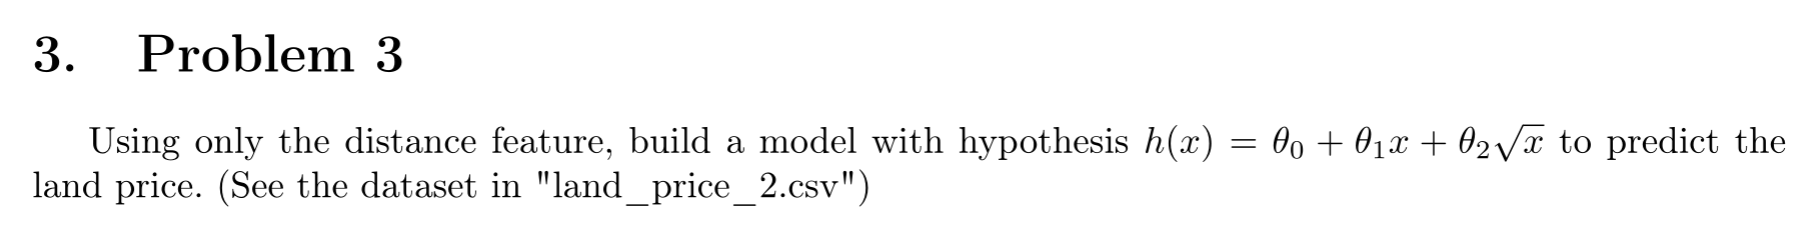

In [11]:
path = "land_price_2.csv"
data = pd.read_csv(path)
data['land_square_root'] = data['land_area'] ** 0.5
data.head()

,land_area,price,land_square_root
0,129,140.9,11.357817
1,214,200.3,14.628739
2,343,280.4,18.520259
3,387,298.8,19.672316
4,454,358.2,21.307276


<Axes: xlabel='land_area', ylabel='price'>

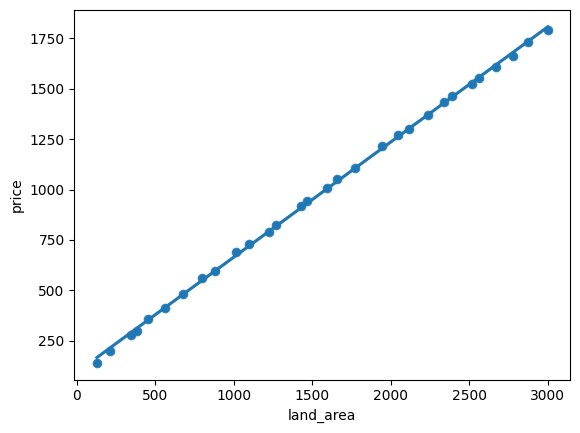

In [12]:
sns.scatterplot(x=data['land_area'], y=data['price'])
sns.regplot(x=data['land_area'], y=data['price'], ci=None)

<Axes: xlabel='land_square_root', ylabel='price'>

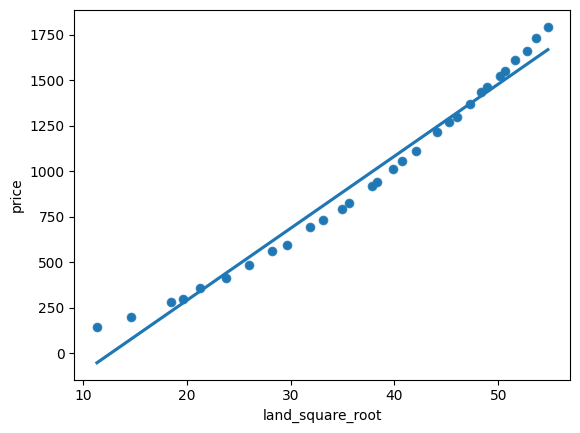

In [13]:
sns.scatterplot(x=data['land_square_root'], y=data['price'])
sns.regplot(x=data['land_square_root'], y=data['price'], ci=None)

In [14]:
path = "land_price_2.csv"
data = pd.read_csv(path)
data['land_square_root'] = data['land_area'] ** 0.5
data.head()

def gradient_descent(X, y, iter, w_lr, b_lr):

    x_min = X.min(axis=0)
    x_max = X.max(axis=0)
    X = (X - x_min) / (x_max - x_min)

    y_min = y.min()
    y_max = y.max()
    y = (y - y_min) / (y_max - y_min)

    m = len(y)
    w_land = 0
    w_land_square_root = 0
    b = 0

    for i in range(iter):

        y_new = w_land * X[:, 0] + w_land_square_root * X[:, 1] + b

        error = y_new - y

        weight_land = (1/m) * np.sum(error * X[:, 0])
        weight_land_square = (1/m) * np.sum(error * X[:, 1])
        bias = (1/m) * np.sum(error)

        w_land = w_land - w_lr * weight_land
        w_land_square_root = w_land_square_root - w_lr * weight_land_square
        b = b - b_lr * bias

    y_new = w_land * X[:, 0] + w_land_square_root * X[:, 1] + b
    ss_res = np.sum((y - y_new) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    loss = np.mean((y - y_new) ** 2)
    mse = np.mean((y - y_new) ** 2)

    return w_land, w_land_square_root, b, loss, r_squared, mse

X = data[['land_area', 'land_square_root']].values
y = data['price'].values

a = gradient_descent(X, y, iter=2000, w_lr=0.01, b_lr=0.01)
print(f"{'='*4} Model {'='*4}")
print(f"land_area weight : {a[0]:.6f}")
print(f"land_square_root weight: {a[1]:.6f}")
print(f"intercept : {a[2]:.6f}")
print(f"Model: y = {a[0]:.2f} * land_area + {a[1]:.2f} * land_square_root + {a[2]:.2f}")
print(f"R-squared: {a[4]:.6f} or {a[4]*100:.2f}%")
print(f"MSE: {a[5]:.6f}")

==== Model ====
land_area weight : 0.494181
land_square_root weight: 0.448150
intercept : -0.001454
Model: y = 0.49 * land_area + 0.45 * land_square_root + -0.00
R-squared: 0.990103 or 99.01%
MSE: 0.000884
